# 19 — Las 7 ligas comparadas

Los notebooks 18 analizan **una liga cada uno**. Este pone las siete juntas para responder qué es propio de cada liga
y qué se repite en todas: Liga MX, Premier League, La Liga, Serie A, Bundesliga, Ligue 1 y Eredivisie, de 2010-11 a
2025-26.

Todo se calcula con `liga.comparativa`, que por dentro llama a las **mismas funciones** que cada notebook por liga
(`resumen_equipos`, `porteros_liga`, `estabilidad`), así que ninguna cifra puede desviarse de lo que muestra su liga
por separado.

**Qué se compara**

- **Plantillas**: jugadores para el 80% de los minutos (rotación), % de minutos de extranjeros y de jugadores sub-21,
  edad ponderada por minutos. Por temporada, mediana de los equipos de cada liga.
- **Porteros**: % de paradas, goles recibidos por partido y % de partidos con portería a cero. Totales de cada liga.
- **Correlaciones**: qué tanto se repite una métrica de un jugador de una temporada a la siguiente (estabilidad) y
  qué se asocia con los puntos por partido de un equipo.

**Cuidado al comparar ligas**: los tamaños y calendarios no son iguales (18 o 20 equipos; 34 o 38 jornadas; Liga MX
suma Apertura y Clausura; 2019-20 se cortó por COVID en varias ligas), por eso todo está en tasas o medianas, nunca en
totales. Y los datos tienen huecos propios de cada liga (p. ej. Liga MX y Eredivisie no tienen paradas en 2018-19).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from futbol_bd import estilo, fantasy, liga, plantillas

LIGAS = ["Liga MX", "Premier League", "La Liga", "Serie A", "Bundesliga", "Ligue 1", "Eredivisie"]
# Un color fijo por liga en todo el notebook (paleta categórica validada para daltonismo).
COLOR = dict(zip(LIGAS, estilo.CATEGORICA))
FIGURAS = RAIZ / "output" / "figures" / "ligas"
FIGURAS.mkdir(parents=True, exist_ok=True)
estilo.aplicar()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)

## 1. Los datos

Se construyen las dos tablas del proyecto una sola vez (jugador-equipo-temporada y jugador-temporada) y se pasan a
`liga.comparativa`, que devuelve las series por liga-temporada y un resumen de una cifra por liga.

In [2]:
filas = plantillas.unir_tablas_extra(plantillas.limpiar_panel(plantillas.cargar_panel_crudo()))
jt = fantasy.puntos_fantasy(plantillas.agregar_por_temporada(filas))
series, resumen = liga.comparativa(filas, jt, LIGAS)
TEMPORADAS = sorted(series["temporada_inicio"].unique())

resumen.set_index("league")[["temporadas", "jugadores", "equipos"]]

,temporadas,jugadores,equipos
league,,,
Liga MX,16,2569,27
Premier League,16,2778,41
La Liga,16,3006,35
Serie A,16,3029,41
Bundesliga,16,2498,32
Ligue 1,16,3200,37
Eredivisie,16,2905,29


## 2. Plantillas: rotación, extranjeros, juveniles y edad

Cada línea es la mediana de los equipos de esa liga en esa temporada.

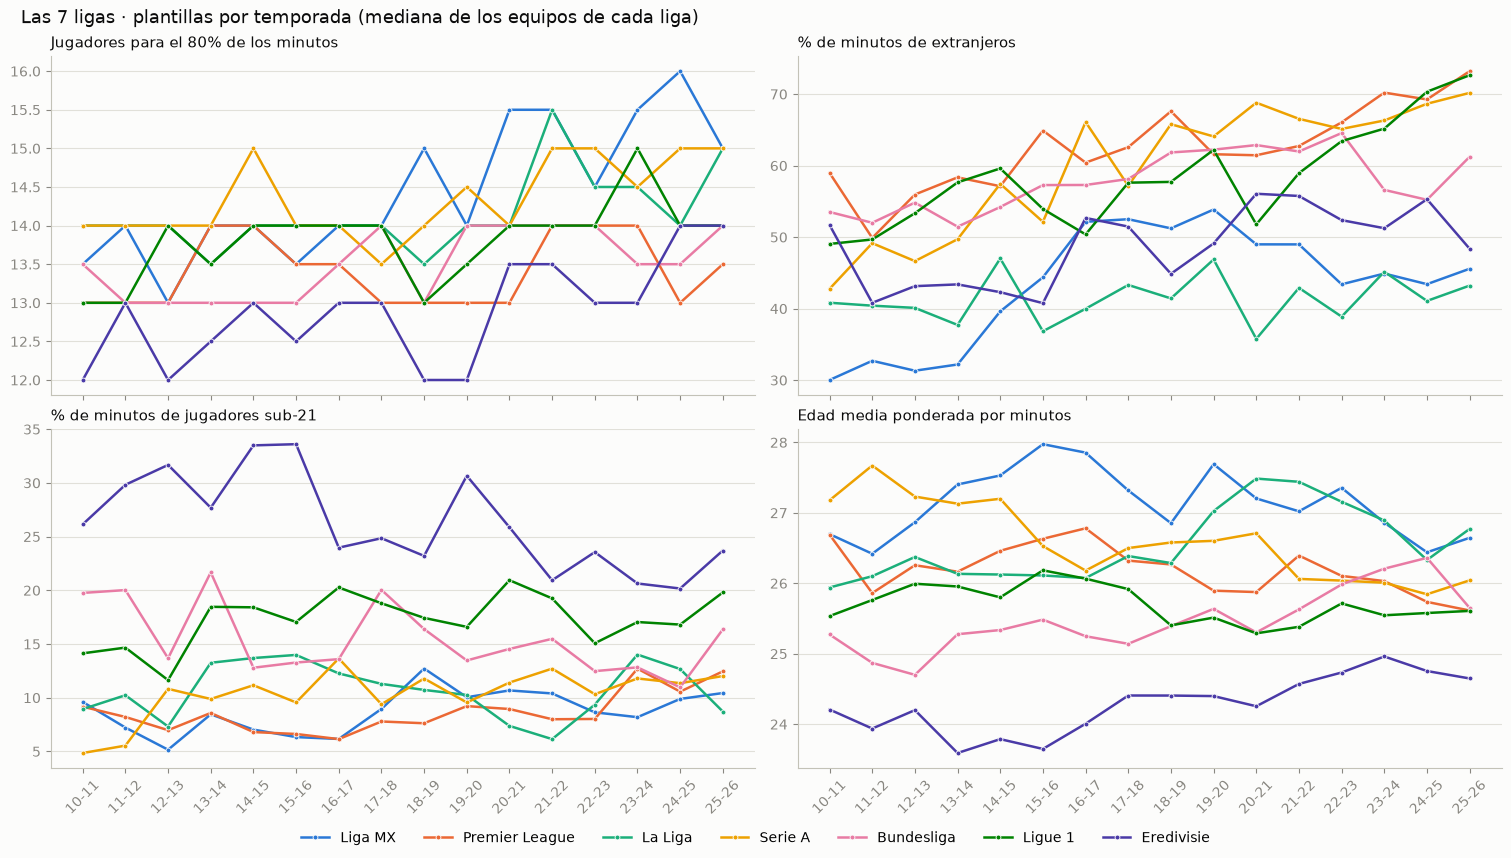

In [3]:
def paneles_de_series(columnas, titulo, archivo, filas_cols, tamano):
    """Un panel por métrica; dentro de cada panel, una línea por liga con su color fijo."""
    fig, axs = plt.subplots(*filas_cols, figsize=tamano, sharex=True, constrained_layout=True)
    for ax, col in zip(np.ravel(axs), columnas):
        for nombre in LIGAS:
            d = series[series["league"] == nombre].set_index("temporada_inicio").reindex(TEMPORADAS)
            ax.plot(TEMPORADAS, d[col], color=COLOR[nombre], linewidth=1.8, marker="o", markersize=3.5,
                    markeredgecolor=estilo.SUPERFICIE, markeredgewidth=0.6, label=nombre)
        ax.set_title(liga.SERIES_COMPARABLES[col])
        estilo.rejilla_y(ax)
    for ax in np.ravel(axs)[-filas_cols[1]:]:
        estilo.etiquetas_temporada(ax, TEMPORADAS)
    fig.legend(*np.ravel(axs)[0].get_legend_handles_labels(), loc="outside lower center", ncols=len(LIGAS))
    fig.suptitle(titulo, x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
    fig.savefig(FIGURAS / archivo, dpi=150)
    plt.show()


paneles_de_series(["jugadores_80pct", "pct_min_extranjeros", "pct_min_sub21", "edad_ponderada"],
                  "Las 7 ligas · plantillas por temporada (mediana de los equipos de cada liga)",
                  "comparativa_plantillas.png", (2, 2), (15, 8.5))

Cuatro lecturas:

- **Rotación**: la **Eredivisie** es la más concentrada (12-14 jugadores para el 80% de los minutos) y la **Liga MX**
  la que más rotó con el tiempo (de 13.5 a 15-16, con el salto de 2020). Premier y Bundesliga son las más estables
  (13-14 en los 15 años).
- **Extranjeros**: hay dos mundos. **Premier (73%), Ligue 1 (72.6%) y Serie A (70.2%)** terminan el periodo con siete
  de cada diez minutos en pies extranjeros, tras subir sin parar. **La Liga (43%) y Eredivisie (48%)** se quedaron
  donde empezaron, y la **Liga MX** subió de 30% a 54% y bajó a 45%.
- **Juveniles**: la **Eredivisie** juega en otra categoría — entre 20% y 33.6% de los minutos para menores de 22
  años, el doble o el triple que Premier, La Liga, Serie A o Liga MX (5-13%). Ligue 1 y Bundesliga están en medio
  (12-21%).
- **Edad**: las siete ligas convergen. Liga MX y Serie A empezaron siendo las más viejas (27-28 años de edad
  ponderada) y hoy están en 26-26.8, cerca de Premier y Ligue 1 (25.6); la Eredivisie sigue siendo la más joven
  (24.6).

## 3. Porteros

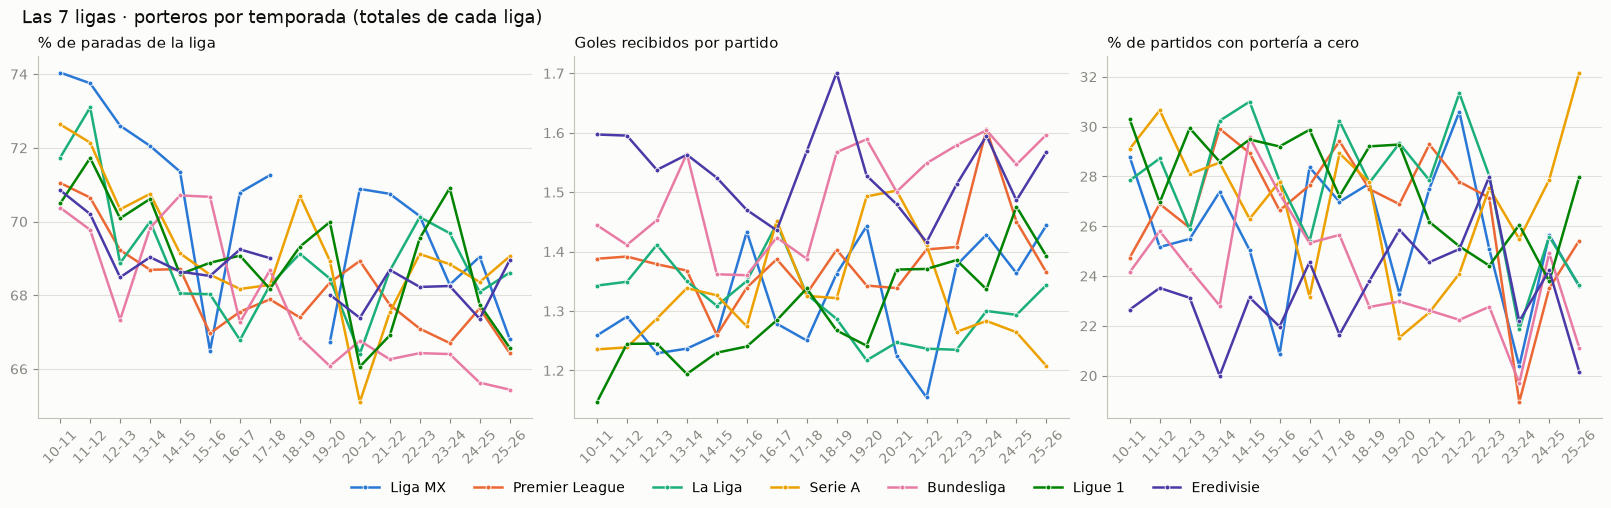

In [4]:
paneles_de_series(["pct_paradas", "goles_recibidos_por_partido", "pct_porterias_cero"],
                  "Las 7 ligas · porteros por temporada (totales de cada liga)",
                  "comparativa_porteros.png", (1, 3), (16, 5))

- **El % de paradas baja en las siete ligas**, entre 2 y 7 puntos en 15 años. La **Bundesliga** termina más abajo
  (65.4%) y **Eredivisie y La Liga** más arriba (69.0% y 68.6%).
- **Goles recibidos por partido**: **Bundesliga (1.60) y Eredivisie (1.57)** son las más goleadas en 2025-26; la
  **Serie A (1.21)** y **La Liga (1.34)**, las que menos. La Ligue 1 hizo el viaje más largo: era la menos goleada del
  panel en 2010-11 (1.15) y hoy está en 1.39.
- **Porterías a cero**: el reflejo de lo anterior — escasas en Bundesliga y Eredivisie (20-25%), abundantes en Serie A
  (32.2% en 2025-26, su récord del periodo).

Que el % de paradas caiga en todas a la vez sugiere una causa común (más tiros claros, o un cambio en cómo se cuentan
los tiros a puerta), no que los porteros de una liga concreta hayan empeorado.

## 4. Lo que se repite en todas: correlaciones

Dos preguntas, una por panel:

- **¿La métrica es del jugador?** Correlación entre una temporada y la siguiente del mismo jugador (1,500+ minutos en
  ambas). Se comparan las dos medidas de "impacto" con una medida individual de referencia (goles sin penal por 90 de
  los delanteros).
- **¿Qué se asocia con los puntos del equipo?** Correlación de Spearman entre puntos por partido y tres cosas:
  cuántos jugadores necesita para el 80% de sus minutos (rotación), cuánto depende de su máximo goleador y cuántos
  goles mete.

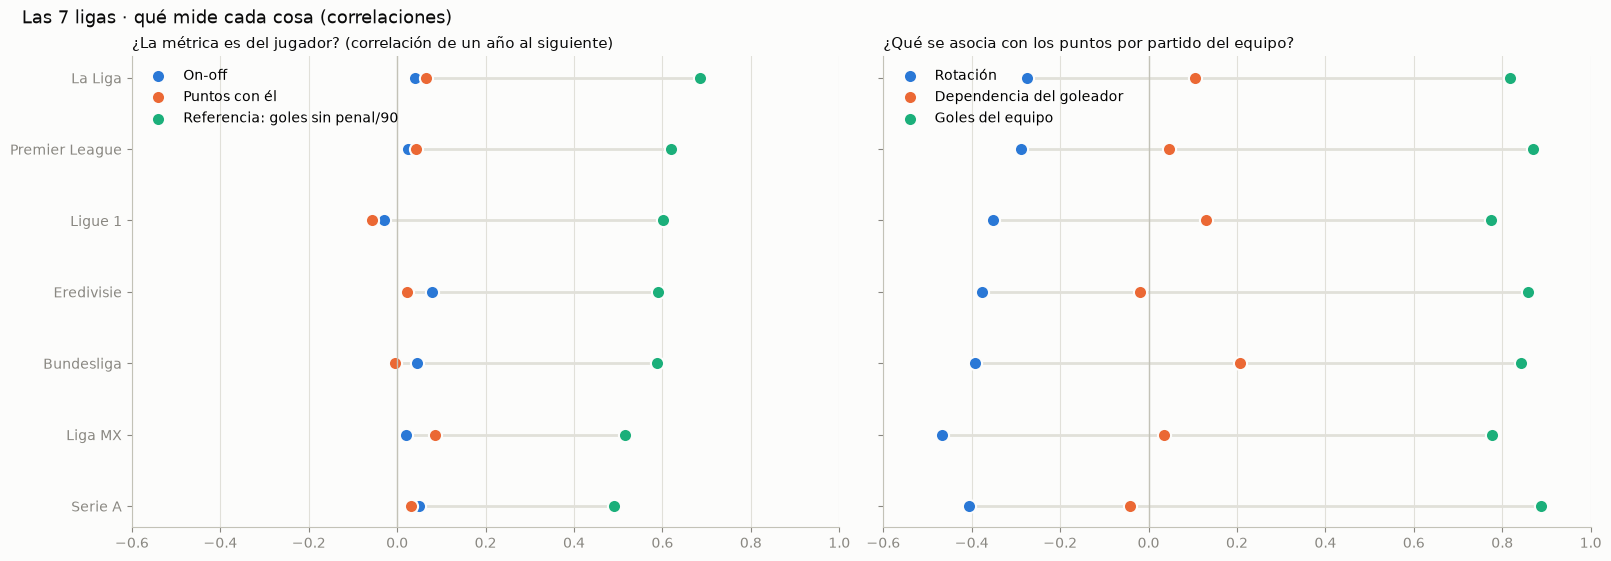

,estab_on_off,estab_ppg_extra,estab_referencia,estab_paradas,estab_porterias_cero,rho_rotacion_puntos,rho_dependencia_puntos,rho_goles_puntos
league,,,,,,,,
Liga MX,0.02,0.09,0.52,0.30,0.22,-0.47,0.04,0.78
Premier League,0.02,0.04,0.62,0.30,0.36,-0.29,0.05,0.87
La Liga,0.04,0.07,0.69,0.27,0.40,-0.28,0.11,0.82
Serie A,0.05,0.03,0.49,0.35,0.45,-0.41,-0.04,0.89
Bundesliga,0.04,-0.01,0.59,0.34,0.39,-0.39,0.21,0.84
Ligue 1,-0.03,-0.06,0.60,0.35,0.34,-0.35,0.13,0.78
Eredivisie,0.08,0.02,0.59,0.26,0.42,-0.38,-0.02,0.86


In [5]:
grupos = [
    ("¿La métrica es del jugador? (correlación de un año al siguiente)",
     [("estab_on_off", "On-off"), ("estab_ppg_extra", "Puntos con él"),
      ("estab_referencia", "Referencia: goles sin penal/90")]),
    ("¿Qué se asocia con los puntos por partido del equipo?",
     [("rho_rotacion_puntos", "Rotación"), ("rho_dependencia_puntos", "Dependencia del goleador"),
      ("rho_goles_puntos", "Goles del equipo")]),
]
orden = resumen.sort_values("estab_referencia")["league"].tolist()   # ligas ordenadas por la referencia individual
fig, axs = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True, constrained_layout=True)
for ax, (titulo, medidas) in zip(axs, grupos):
    for y, nombre in enumerate(orden):
        fila = resumen[resumen["league"] == nombre].iloc[0]
        valores = [fila[c] for c, _ in medidas]
        ax.plot([min(valores), max(valores)], [y, y], color=estilo.REJILLA, linewidth=2, zorder=1)
        for (col, etiqueta), color in zip(medidas, [estilo.AZUL, estilo.NARANJA, estilo.AQUA]):
            ax.scatter(fila[col], y, s=90, color=color, edgecolors=estilo.SUPERFICIE, linewidths=1.5, zorder=2,
                       label=etiqueta if y == 0 else None)
    ax.axvline(0, color=estilo.EJE, linewidth=1)
    ax.set_yticks(range(len(orden)), orden)
    ax.set_xlim(-0.6, 1)
    ax.set_title(titulo)
    ax.grid(axis="x", color=estilo.REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(loc="upper left")            # a la izquierda del 0: la zona vacía en los dos paneles
fig.suptitle("Las 7 ligas · qué mide cada cosa (correlaciones)", x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / "comparativa_correlaciones.png", dpi=150)
plt.show()

resumen.set_index("league")[["estab_on_off", "estab_ppg_extra", "estab_referencia", "estab_paradas",
                             "estab_porterias_cero", "rho_rotacion_puntos", "rho_dependencia_puntos",
                             "rho_goles_puntos"]].round(2)

El panel izquierdo es el resultado más importante de todo este trabajo:

- **El on-off no mide al jugador en ninguna liga**: entre **−0.03 (Ligue 1) y 0.08 (Eredivisie)**. Los "puntos por
  partido con él" tampoco (de −0.06 a 0.09).
- **La medida individual de referencia sí se repite**: los goles sin penal por 90 de un delantero van de **0.49
  (Serie A) a 0.69 (La Liga)**. La misma prueba, aplicada a la misma tabla de datos, distingue perfectamente una
  métrica que es del jugador de una que no lo es.

El panel derecho, sobre lo que se asocia con los puntos del equipo:

- **Los goles del equipo**, en todas: de 0.78 (Liga MX y Ligue 1) a 0.89 (Serie A).
- **Rotar más va con perder**, en todas: de −0.28 (La Liga) a −0.47 (Liga MX).
- **Depender del goleador no dice nada**: de −0.04 (Serie A) a 0.21 (Bundesliga), sin un patrón claro.

De paso, las métricas de portero: el % de paradas se repite de forma parecida en todas (0.26-0.35) y las porterías a
cero dependen mucho más de la liga (0.22 en Liga MX contra 0.45 en Serie A): donde hay equipos dominantes durante
años, dejar la portería en cero se hereda de la defensa.

## 5. Tabla resumen: dónde está cada liga en la última temporada y en todo el periodo

In [6]:
ultima = series[series["temporada_inicio"] == TEMPORADAS[-1]].set_index("league")
primera = series[series["temporada_inicio"] == TEMPORADAS[0]].set_index("league")
tabla = pd.DataFrame({
    "Rotación (80% min.)": ultima["jugadores_80pct"],
    "% extranjeros 10-11": primera["pct_min_extranjeros"],
    "% extranjeros 25-26": ultima["pct_min_extranjeros"],
    "% min. sub-21 25-26": ultima["pct_min_sub21"],
    "Edad 25-26": ultima["edad_ponderada"],
    "% paradas 10-11": primera["pct_paradas"],
    "% paradas 25-26": ultima["pct_paradas"],
    "Goles recibidos/partido 25-26": ultima["goles_recibidos_por_partido"],
}).join(resumen.set_index("league")[["rho_rotacion_puntos", "estab_on_off", "estab_referencia"]])
tabla.loc[LIGAS].round(2)

,Rotación (80% min.),% extranjeros 10-11,% extranjeros 25-26,% min. sub-21 25-26,Edad 25-26,% paradas 10-11,% paradas 25-26,Goles recibidos/partido 25-26,rho_rotacion_puntos,estab_on_off,estab_referencia
league,,,,,,,,,,,
Liga MX,15.0,30.02,45.58,10.44,26.65,74.04,66.81,1.44,-0.47,0.02,0.52
Premier League,13.5,58.98,73.21,12.45,25.61,71.05,66.43,1.37,-0.29,0.02,0.62
La Liga,15.0,40.83,43.22,8.72,26.77,71.74,68.61,1.34,-0.28,0.04,0.69
Serie A,15.0,42.77,70.17,12.02,26.04,72.64,69.05,1.21,-0.41,0.05,0.49
Bundesliga,14.0,53.52,61.24,16.36,25.65,70.38,65.44,1.60,-0.39,0.04,0.59
Ligue 1,14.0,49.05,72.64,19.80,25.61,70.49,66.58,1.39,-0.35,-0.03,0.60
Eredivisie,14.0,51.70,48.37,23.71,24.65,70.85,68.95,1.57,-0.38,0.08,0.59


Los extremos de la tabla, en una línea: la **Eredivisie** es la liga joven, concentrada y goleada; la **Premier** y la
**Ligue 1**, las más extranjerizadas; **La Liga**, la más local y la que menos goles recibe junto con la **Serie A**;
la **Liga MX**, la que más rota y la que más castiga rotar (−0.47); la **Bundesliga**, la más estable en plantillas y
la más goleada.

## 6. Conclusiones

**Lo que cambia entre ligas** (identidad de cada una):

| | Liga más… | |
|---|---|---|
| Joven y con más minutos juveniles | **Eredivisie** | 24.6 años; 23.7% de minutos sub-21 en 2025-26 |
| Extranjerizada | **Premier** (73%) y **Ligue 1** (72.6%) | La Liga se quedó en 43% |
| Goleada | **Bundesliga** (1.60 por partido) | Serie A la que menos (1.21) |
| Rotadora | **Liga MX** (15-16 jugadores para el 80% de los minutos) | Eredivisie la más concentrada (14) |
| Estable en plantillas | **Bundesliga** y **Premier** (13-14 en 15 años) | |

**Lo que se repite en las siete** (y por eso es lo más confiable):

1. **El "impacto en cancha" medido con totales de temporada es ruido**: on-off entre −0.03 y 0.08 de un año al
   siguiente, contra 0.49-0.69 de una medida individual. Ninguna liga se salva.
2. **Rotar mucho va de la mano con perder** (−0.28 a −0.47), aunque la causa corre en los dos sentidos.
3. **Lo que se asocia con los puntos es meter goles** (0.78 a 0.89), no de quién vengan: la dependencia del goleador
   no explica nada (−0.04 a 0.21).
4. **El % de paradas de la liga cae en las siete** en estos 15 años.

**Siguiente paso**: el fantasy defensivo (porterías a cero, paradas y goles recibidos ya están en el dataset desde la
Fase 19) para que porteros y defensas tengan un puntaje justo, y con eso repetir estas comparaciones por posición.